# Linearizing Nonlinear Data with a Log Transformation

This notebook demonstrates how a nonlinear exponential relationship can be transformed into a linear relationship using the natural logarithm. We compare a linear model fitted directly to the original data with a linear model fitted after transformation.

**Learning Objectives:**
- Recognize an exponential nonlinear relationship
- Understand why a straight line is inadequate for curved data
- Apply a logarithmic transformation to linearize the relationship
- Convert predictions back to the original scale
- Compare models using $R^2$, MAE, and RMSE

**Prerequisites:**
- Basic Python programming
- Familiarity with NumPy, pandas, and Matplotlib
- Basic understanding of linear regression

In [1]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

## Step 1: Create Nonlinear Sample Data

We generate observations from an exponential process:

$$y = a e^{bx} e^{\varepsilon}$$

where $a$ is the initial level, $b$ is the growth rate, and $\varepsilon$ is random noise. The multiplicative noise keeps every value of $y$ positive, which is required by the logarithm.

In [2]:
# Create reproducible exponential data
rng = np.random.default_rng(RANDOM_STATE)
x = np.linspace(0, 8, 60)
a_true = 3.0
b_true = 0.45
noise = rng.normal(loc=0.0, scale=0.18, size=x.size)
y = a_true * np.exp(b_true * x + noise)

df = pd.DataFrame({"x": x, "y": y})
print("First observations:")
print(df.head(10).round(3))
print(f"\nNumber of observations: {len(df)}")
print(f"All y values are positive: {(df['y'] > 0).all()}")

First observations:
       x      y
0  0.000  3.169
1  0.136  2.644
2  0.271  3.880
3  0.407  4.267
4  0.542  2.695
5  0.678  3.220
6  0.814  4.427
7  0.949  4.344
8  1.085  4.873
9  1.220  4.456

Number of observations: 60
All y values are positive: True


## Step 2: Visualize the Original Relationship

The scatter plot curves upward. This indicates that the change in $y$ is not constant as $x$ increases, so a straight line is unlikely to represent the relationship well.

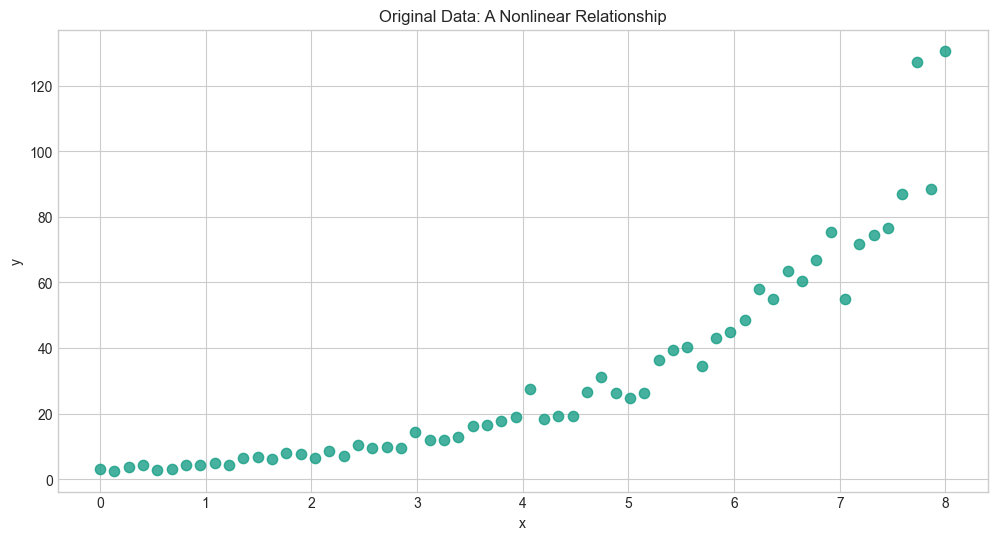

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df["x"], df["y"], color="#179E86", s=55, alpha=0.8)
ax.set(
    title="Original Data: A Nonlinear Relationship",
    xlabel="x",
    ylabel="y"
)
plt.show()

## Step 3: Fit a Linear Model to the Original Data

As a baseline, we fit the model $y = \beta_0 + \beta_1x$. The model can produce a line, but its constant slope cannot follow exponential curvature.

In [4]:
# scikit-learn expects the input features to form a 2D matrix
X = df[["x"]]

raw_model = LinearRegression()
raw_model.fit(X, df["y"])
df["raw_prediction"] = raw_model.predict(X)

print(f"Raw-scale equation: y = {raw_model.intercept_:.3f} "
      f"+ {raw_model.coef_[0]:.3f}x")
print(f"R² on the original scale: "
      f"{r2_score(df['y'], df['raw_prediction']):.3f}")

Raw-scale equation: y = -15.236 + 11.530x
R² on the original scale: 0.792


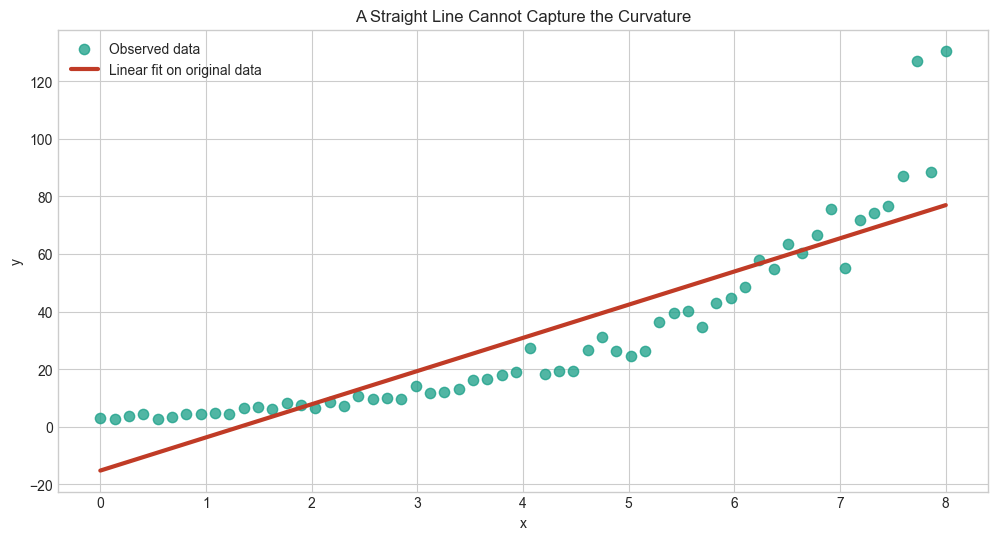

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df["x"], df["y"], color="#179E86", s=55,
           alpha=0.75, label="Observed data")
ax.plot(df["x"], df["raw_prediction"], color="#C03B26",
        linewidth=3, label="Linear fit on original data")
ax.set(
    title="A Straight Line Cannot Capture the Curvature",
    xlabel="x",
    ylabel="y"
)
ax.legend()
plt.show()

## Step 4: Apply the Logarithmic Transformation

Taking the natural logarithm of both sides changes the exponential equation into a linear one:

$$y = a e^{bx} e^{\varepsilon}$$

$$\log(y) = \log(a) + bx + \varepsilon$$

The transformed response $\log(y)$ should therefore have an approximately linear relationship with $x$.

In [6]:
# The logarithm is defined here because every y value is strictly positive
df["log_y"] = np.log(df["y"])

print("Data before and after transformation:")
print(df[["x", "y", "log_y"]].head(10).round(3))

Data before and after transformation:
       x      y  log_y
0  0.000  3.169  1.153
1  0.136  2.644  0.972
2  0.271  3.880  1.356
3  0.407  4.267  1.451
4  0.542  2.695  0.991
5  0.678  3.220  1.169
6  0.814  4.427  1.488
7  0.949  4.344  1.469
8  1.085  4.873  1.584
9  1.220  4.456  1.494


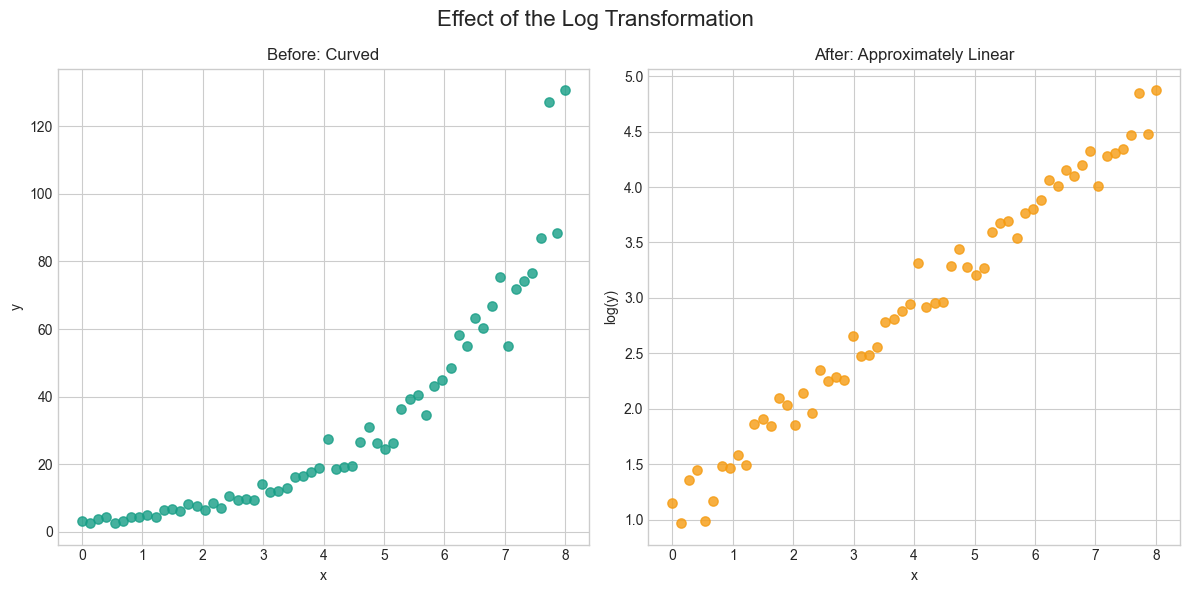

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(df["x"], df["y"], color="#179E86",
                s=45, alpha=0.8)
axes[0].set(title="Before: Curved", xlabel="x", ylabel="y")

axes[1].scatter(df["x"], df["log_y"], color="#F59B11",
                s=45, alpha=0.8)
axes[1].set(title="After: Approximately Linear",
            xlabel="x", ylabel="log(y)")

fig.suptitle("Effect of the Log Transformation", fontsize=16)
fig.tight_layout()
plt.show()

## Step 5: Fit Linear Regression to the Transformed Data

We now fit $\log(y) = \beta_0 + \beta_1x$. The intercept estimates $\log(a)$, while the slope estimates the exponential growth rate $b$.

In [8]:
log_model = LinearRegression()
log_model.fit(X, df["log_y"])
df["predicted_log_y"] = log_model.predict(X)

# Convert predictions from log(y) back to the original y scale
df["log_model_prediction"] = np.exp(df["predicted_log_y"])

estimated_a = np.exp(log_model.intercept_)
estimated_b = log_model.coef_[0]

print(f"Transformed equation: log(y) = {log_model.intercept_:.3f} "
      f"+ {estimated_b:.3f}x")
print(f"Recovered exponential equation: y = {estimated_a:.3f} "
      f"× exp({estimated_b:.3f}x)")
print(f"True parameters: a = {a_true:.3f}, b = {b_true:.3f}")
print(f"R² in log space: "
      f"{r2_score(df['log_y'], df['predicted_log_y']):.3f}")

Transformed equation: log(y) = 1.092 + 0.455x
Recovered exponential equation: y = 2.980 × exp(0.455x)
True parameters: a = 3.000, b = 0.450
R² in log space: 0.983


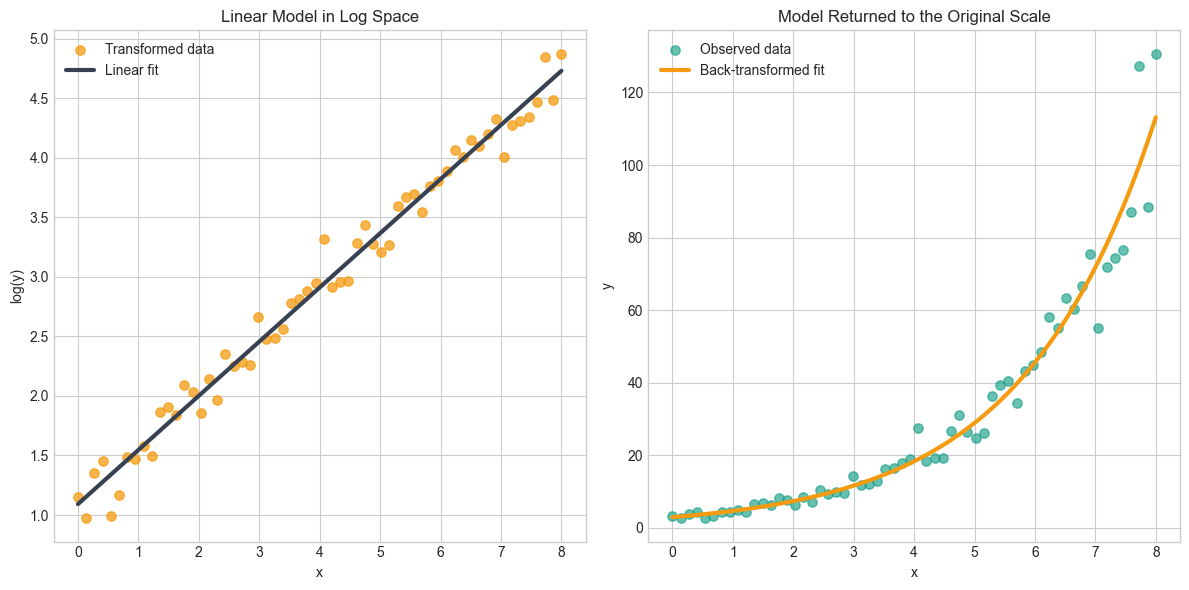

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(df["x"], df["log_y"], color="#F59B11",
                s=45, alpha=0.75, label="Transformed data")
axes[0].plot(df["x"], df["predicted_log_y"], color="#374151",
             linewidth=3, label="Linear fit")
axes[0].set(title="Linear Model in Log Space",
            xlabel="x", ylabel="log(y)")
axes[0].legend()

axes[1].scatter(df["x"], df["y"], color="#179E86",
                s=45, alpha=0.65, label="Observed data")
axes[1].plot(df["x"], df["log_model_prediction"], color="#F59B11",
             linewidth=3, label="Back-transformed fit")
axes[1].set(title="Model Returned to the Original Scale",
            xlabel="x", ylabel="y")
axes[1].legend()

fig.tight_layout()
plt.show()

## Step 6: Compare the Two Approaches

For a fair comparison, both sets of predictions are evaluated on the original $y$ scale. Higher $R^2$ and lower MAE/RMSE indicate a better fit.

In [10]:
def regression_metrics(y_true, y_pred):
    """Return common regression metrics on the same response scale."""
    return {
        "R²": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

comparison = pd.DataFrame({
    "Linear fit on original y": regression_metrics(
        df["y"], df["raw_prediction"]
    ),
    "Linear fit on log(y)": regression_metrics(
        df["y"], df["log_model_prediction"]
    ),
}).T

print("MODEL COMPARISON — METRICS ON THE ORIGINAL y SCALE")
print("=" * 58)
print(comparison.round(3))

MODEL COMPARISON — METRICS ON THE ORIGINAL y SCALE
                             R²     MAE    RMSE
Linear fit on original y  0.792  10.251  13.872
Linear fit on log(y)      0.956   3.578   6.346


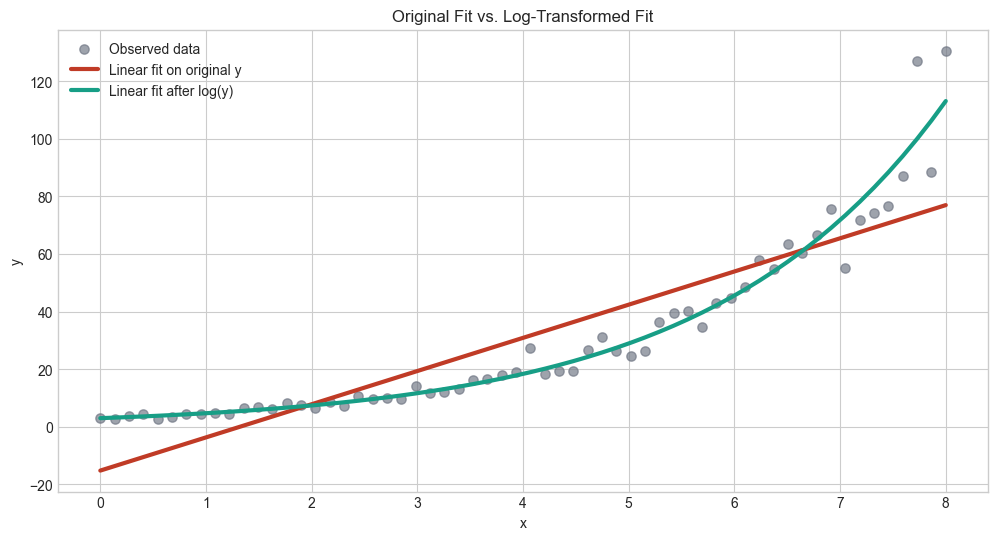

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df["x"], df["y"], color="#6B7280", s=45,
           alpha=0.65, label="Observed data")
ax.plot(df["x"], df["raw_prediction"], color="#C03B26",
        linewidth=3, label="Linear fit on original y")
ax.plot(df["x"], df["log_model_prediction"], color="#179E86",
        linewidth=3, label="Linear fit after log(y)")
ax.set(
    title="Original Fit vs. Log-Transformed Fit",
    xlabel="x",
    ylabel="y"
)
ax.legend()
plt.show()

## Step 7: Inspect the Residuals

Residuals are the differences between observed and predicted values. A systematic curved pattern indicates that the model has missed structure in the data.

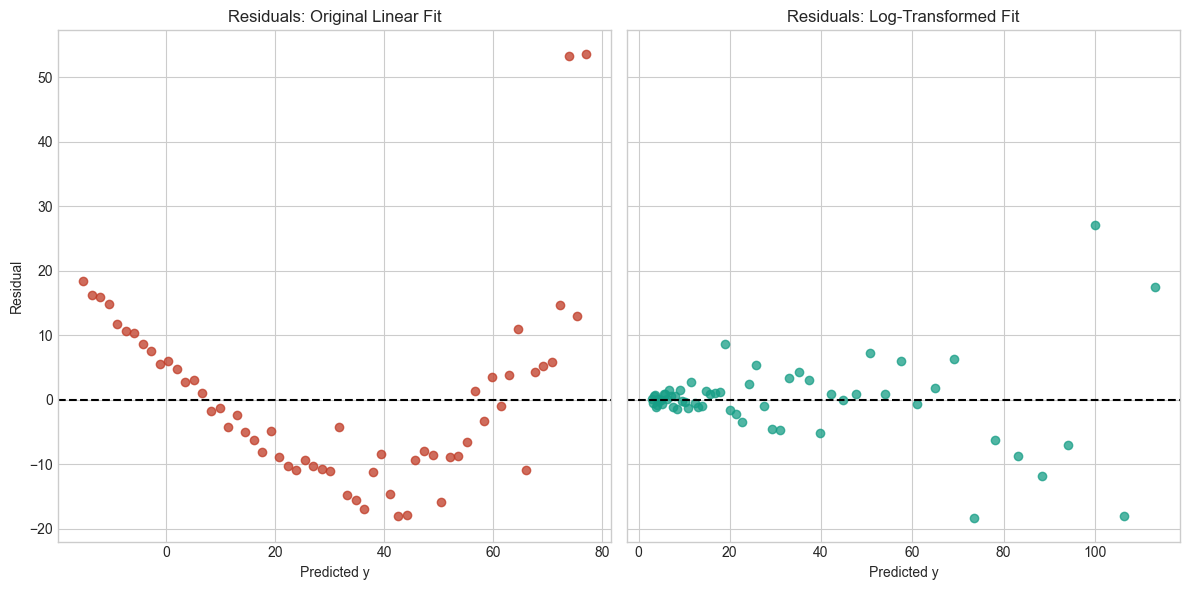

In [12]:
df["raw_residual"] = df["y"] - df["raw_prediction"]
df["log_model_residual"] = df["y"] - df["log_model_prediction"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].scatter(df["raw_prediction"], df["raw_residual"],
                color="#C03B26", alpha=0.75)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(title="Residuals: Original Linear Fit",
            xlabel="Predicted y", ylabel="Residual")

axes[1].scatter(df["log_model_prediction"], df["log_model_residual"],
                color="#179E86", alpha=0.75)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(title="Residuals: Log-Transformed Fit",
            xlabel="Predicted y")

fig.tight_layout()
plt.show()

## Step 8: Practical Considerations

A logarithmic transformation is useful when:
- The response is strictly positive
- The relationship resembles exponential growth or decay
- Variability increases as the response increases
- Multiplicative effects make more sense than additive effects

Important cautions:
- `np.log(y)` is undefined for zero and negative values; do not add an arbitrary constant without a domain-based justification.
- The transformation does not make the original data linear. It creates a scale on which the relationship can be modeled linearly.
- After fitting in log space, use `np.exp()` to return predictions to the original scale.
- A simple exponentiation estimates the conditional median under common log-normal assumptions. Estimating the conditional mean may require a bias correction.
- Select transformations from the data-generating mechanism and residual diagnostics, not only from a higher $R^2$.

## Summary

In this notebook, we transformed an exponential relationship into an approximately linear one:

1. The original data followed $y = ae^{bx}e^{\varepsilon}$ and displayed clear curvature.
2. A straight line fitted directly to $y$ failed to capture that curvature.
3. Applying the natural logarithm produced $\log(y) = \log(a) + bx + \varepsilon$.
4. Linear regression could then estimate the transformed relationship.
5. Applying `np.exp()` returned predictions to the original response scale.
6. Metrics and residual plots showed why the transformed model was more appropriate.

### Key Takeaway

A suitable transformation can reveal a linear relationship on a new scale, allowing a linear model to represent a process that appears nonlinear in its original variables.